## Public demo note

This notebook is included as the main public demo for the mEX analysis. For the public repository, the intended starting files are `mEX_all_predictions.csv`, `features_master_file.csv`, and `features_binary_file.csv`, which are already included in this folder. Some optional recomputation cells in this notebook were originally used during development and depend on additional internal artifacts.


# Analysis of classification using PBC4emp, LLM, BERT, and RF

Notebook for exploring the results obtained in mEX

We provide the most supported pattern for the classification of the exchange. 


# Set up

In [2]:
import pickle
import pandas as pd
import numpy as np
from PBC4cip import PBC4cip
import os
import sys
import random 
import re
from processed_databases.utilities import CEM_utils as cem_utils
from scipy.stats import ttest_ind
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,recall_score, precision_score, f1_score
import nltk
import test_BERT as bert_tester
import database_processing_package as data_processer
import exchange_processing as exchange_processer
from classifiers.course_grained_emotion import emotion_reductor as em_red
from processed_databases.utilities import lexicon_analysis as lexicon
import math
from matplotlib.pylab import norm
import matplotlib.pyplot as plt
from processed_databases.utilities.latex_table import build_latex_performance_table
import seaborn as sns


### utilities

In [3]:
def get_classification_metrics(y_true, y_pred):
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    conf_matrix = confusion_matrix(y_true, y_pred)
    results = {'accuracy': accuracy, 'f1': f1, 'precision': precision, 'recall': recall, 'conf_matrix': conf_matrix}
    return results

def print_metrics_summary(metrics_dict):
    for key in metrics_dict:
        if key == 'conf_matrix':
            print('Confusion Matrix:')
            print(metrics_dict[key])
        else:
            print(f"{key}: {metrics_dict[key]}")

def run_model_metrics(dataframe, prediction_columns, model_name, multi_label_col='empathy', binary_label_col='empathy_binary'):
    summary = {}
    for pred in prediction_columns:
        print(f"Calculating metrics for {model_name} -> {pred}...")
        is_binary = bool(re.search(r'(^|_)2$', pred))

        if is_binary:
            current_predictions = dataframe[pred]
            class_true = dataframe[binary_label_col]
            metrics = get_classification_metrics(class_true, current_predictions)

            summary[pred] = {
                'accuracy': metrics['accuracy'],
                'f1': metrics['f1'],
                'precision': metrics['precision'],
                'recall': metrics['recall'],
                'conf_matrix': metrics['conf_matrix']
            }
            print('CEM is not calculated for binary predictions.')
            print_metrics_summary(summary[pred])
        else:
            current_predictions = dataframe[pred]
            class_true = dataframe[multi_label_col]
            metrics = get_classification_metrics(class_true, current_predictions)
            cem_score = cem_utils.get_cem(current_predictions, dataframe[[multi_label_col]])

            summary[pred] = {
                'accuracy': metrics['accuracy'],
                'cem': cem_score,
                'f1': metrics['f1'],
                'precision': metrics['precision'],
                'recall': metrics['recall'],
                'conf_matrix': metrics['conf_matrix']
            }
            print_metrics_summary(summary[pred])

    return summary

def get_cosine_similarity_video(dataframe_row):

    speaker_va_vector = np.array([dataframe_row['valence_speaker_video'], dataframe_row['arousal_speaker_video']])
    listener_va_vector = np.array([dataframe_row['valence_listener_video'], dataframe_row['arousal_listener_video']])
    if (np.any(speaker_va_vector) == False) or (np.any(listener_va_vector) == False):
        cosine = -1
    else:
        cosine = np.dot(speaker_va_vector,listener_va_vector)/(norm(speaker_va_vector)*norm(listener_va_vector))
    return cosine

def get_VAD_values_for_both(dataframe):
    #setup lexicon utilities
    lexicon_df,wnl,stp_wrds = lexicon.setup_lexicon('utilities/BipolarScale/NRC-VAD-Lexicon.txt')
    print("Extracting VAD values for speaker utterances...")
    dataframe['vad_speaker'] = dataframe['speaker_utterance'].progress_apply(lexicon.get_avg_vad, args = (lexicon_df,wnl,stp_wrds)) 
    print("Extracting VAD values for listener utterances...")
    dataframe['vad_listener'] = dataframe['listener_utterance'].progress_apply(lexicon.get_avg_vad, args = (lexicon_df,wnl,stp_wrds)) 
    dataframe[['valence_speaker','arousal_speaker','dominance_speaker']] = pd.DataFrame(dataframe.vad_speaker.tolist(),index = dataframe.index)
    dataframe[['valence_listener','arousal_listener','dominance_listener']] = pd.DataFrame(dataframe.vad_listener.tolist(),index = dataframe.index)
    dataframe = dataframe.drop(columns = ['vad_speaker','vad_listener'])
    #print(vad)
    return dataframe

### Load main classification model and EX

In [4]:
#Relevant directories
current_dir = os.getcwd() #get directory of the repository
main_dir = current_dir+'/../../' #Groups folder
print(current_dir)

# EX Database
database_dir = '/processed_databases/EmpatheticExchanges/EmpatheticExchanges_LEX_LLM_full.csv'
database = pd.read_csv(current_dir + database_dir)
print(database['empathy'].unique())


/home/haru/Desktop/projects/MultimodalEX/classifiers/PBC4emp
[3 1 2]


In [5]:
# Select Main Model for PBC4emp
model_directory = current_dir + '/processed_databases/Lex_LLM_features_pbc4emp.sav'
#load model
pbc = pickle.load(open(model_directory, 'rb'))
#print features relevant for the model
att_lst = [attribute[0] for attribute in pbc.dataset.Attributes]
print('Features for the model: ')
for attribute in att_lst:
    print(attribute, end = ' ')


Features for the model: 
s_word_len l_word_len arousal_listener valence_listener who sentiment emotional_reaction interpretations explorations intent arousal_speaker valence_speaker speaker_who speaker_sentiment dominance_speaker dominance_listener mimicry 

### Load mEX and predictions

In [6]:


# mEX database
mex = pd.read_parquet(current_dir + '/processed_databases/mex_fusion_lex_llm.parquet')
print(mex['empathy'].unique())



# modify master dataframe to include the fused predictions for the video features
optimal_weight = 70
modified_master_df = pd.read_csv(current_dir+'/results/lexllm_video_predictions/test_with_'+str(optimal_weight/100)+'/mEX_fusion_'+str(optimal_weight/100)+'.csv')
mex['arousal_listener_fused'] = modified_master_df['arousal_listener']
mex['valence_listener_fused'] = modified_master_df['valence_listener']
mex['arousal_speaker_fused'] = modified_master_df['arousal_speaker']
mex['valence_speaker_fused'] = modified_master_df['valence_speaker']
mex['mimicry_fused'] = mex['mimicry_video_face']
mex['id'] = mex['speaker_id']


# Get all predictions 

rf_preds = pd.read_csv(current_dir+'/results/lexllm_video_predictions/mEX_rf_predictions.csv')
pbc_preds = pd.read_csv(current_dir+'/results/lexllm_video_predictions/mEX_pbc_predictions.csv')
bert_preds = pd.read_csv(current_dir+'/results/lexllm_video_predictions/mEX_bert_predictions.csv')
gpt_preds = pd.read_csv(current_dir+'/processed_databases/mex_fusion_lex_llm_multimodal_baselines_llm_allrows.csv')

pattern = re.compile(r'(pbc|rf|bert).*?\d', re.IGNORECASE)

rf_cols = [c for c in rf_preds.columns if pattern.search(c)]
pbc_cols = [c for c in pbc_preds.columns if pattern.search(c)]
bert_cols = [c for c in bert_preds.columns if pattern.search(c)]
llm_cols = ['multimodal_llm_av', 'multimodal_llm_mimicry', 'multimodal_llm_av_mimicry', 'multimodal_llm_text']

prediction_cols = rf_cols + pbc_cols + bert_cols

for col in rf_cols:
    mex[col] = rf_preds[col].astype(int)
for col in pbc_cols:
    mex[col] = pbc_preds[col].astype(int)
for col in bert_cols:
    mex[col] = bert_preds[col].astype(int)
for col in llm_cols:
    mex[col] = gpt_preds[col].astype(int)

#rename LLM columns to have the same format
mex['llm_va_3'] = mex['multimodal_llm_av'].astype(int)
print(mex['llm_va_3'].unique())
mex['llm_m_3'] = mex['multimodal_llm_mimicry'].astype(int)
mex['llm_vam_3'] = mex['multimodal_llm_av_mimicry'].astype(int) 
mex['llm_va_2'] = mex.apply(lambda x: 1 if (int(x['llm_va_3']) >= 1)  else 0, axis = 1)
mex['llm_m_2'] = mex.apply(lambda x: 1 if (int(x['llm_m_3']) >= 1)  else 0, axis = 1)
mex['llm_vam_2'] = mex.apply(lambda x: 1 if (int(x['llm_vam_3']) >= 1)  else 0, axis = 1)
mex['llm_t_3'] = mex['multimodal_llm_text'].astype(int)
mex['llm_t_2'] = mex.apply(lambda x: 1 if (int(x['llm_t_3']) >= 1)  else 0, axis = 1)
mex = mex.drop(columns = llm_cols)
llm_cols = ['llm_va_3', 'llm_m_3', 'llm_vam_3', 'llm_t_3', 'llm_va_2', 'llm_m_2', 'llm_vam_2', 'llm_t_2']
mex['empathy_binary'] = pbc_preds['empathy_binary']

#Delete exchanges with issues
mex.drop(mex[mex.id == 'sub_14_conv_4'].index, inplace=True)
mex.drop(mex[mex.id == 'sub_13_conv_7'].index, inplace=True)
mex.drop(mex[mex.id == 'sub_12_conv_7'].index, inplace=True)
mex.drop(mex[mex.id == 'sub_12_conv_7'].index, inplace=True)
mex.drop(mex[mex.id == 'sub_7_conv_1'].index, inplace=True)
mex = mex.reset_index(drop=True)

mex.to_csv(current_dir + '/mEX_all_predictions.csv', index=False)
pbc_cols


[0. 1. 2.]
[1 0 2]


['pbc_t_2',
 'pbc_t_3',
 'pbc_m_3',
 'pbc_m_2',
 'pbc_va_3',
 'pbc_va_2',
 'pbc_vam_3',
 'pbc_vam_2']

### PBC4emp

In [7]:
pbc_metrics_summary = run_model_metrics(mex, pbc_cols, 'PBC4emp')

Calculating metrics for PBC4emp -> pbc_t_2...
CEM is not calculated for binary predictions.
accuracy: 0.6129032258064516
f1: 0.5679442508710801
precision: 0.665
recall: 0.603125
Confusion Matrix:
[[ 45 105]
 [ 15 145]]
Calculating metrics for PBC4emp -> pbc_t_3...
accuracy: 0.4032258064516129
cem: 0.5993384561852874
f1: 0.3666657618776182
precision: 0.43972033257747545
recall: 0.4304683023389071
Confusion Matrix:
[[45 34 71]
 [10 12 57]
 [ 5  8 68]]
Calculating metrics for PBC4emp -> pbc_m_3...
accuracy: 0.4096774193548387
cem: 0.6035130498980577
f1: 0.3761314727326048
precision: 0.4391985145624564
recall: 0.43312392561337704
Confusion Matrix:
[[48 34 68]
 [12 13 54]
 [ 5 10 66]]
Calculating metrics for PBC4emp -> pbc_m_2...
CEM is not calculated for binary predictions.
accuracy: 0.6161290322580645
f1: 0.5763422337065747
precision: 0.6610675039246467
recall: 0.606875
Confusion Matrix:
[[ 48 102]
 [ 17 143]]
Calculating metrics for PBC4emp -> pbc_va_3...
accuracy: 0.47096774193548385
ce

### BERT

In [8]:
bert_metrics_summary = run_model_metrics(mex, bert_cols, 'BERT')

Calculating metrics for BERT -> bert_2...
CEM is not calculated for binary predictions.
accuracy: 0.5580645161290323
f1: 0.4508023948998461
precision: 0.6613391910316619
recall: 0.544375
Confusion Matrix:
[[ 18 132]
 [  5 155]]
Calculating metrics for BERT -> bert_3...
accuracy: 0.2967741935483871
cem: 0.5234742992929144
f1: 0.21983624169864546
precision: 0.3666743367227676
recall: 0.3446309319164453
Confusion Matrix:
[[ 18  24 108]
 [  3   1  75]
 [  2   6  73]]


### RF

In [9]:
rf_metrics_summary = run_model_metrics(mex, rf_cols, 'LLM')

Calculating metrics for LLM -> rf_t_2...
CEM is not calculated for binary predictions.
accuracy: 0.5612903225806452
f1: 0.4405817101003132
precision: 0.7391581632653061
recall: 0.546875
Confusion Matrix:
[[ 15 135]
 [  1 159]]
Calculating metrics for LLM -> rf_t_3...
accuracy: 0.31290322580645163
cem: 0.524194873767435
f1: 0.2147320322747004
precision: 0.45419570267131243
recall: 0.37088607594936707
Confusion Matrix:
[[ 15   6 129]
 [  1   1  77]
 [  0   0  81]]
Calculating metrics for LLM -> rf_m_3...
accuracy: 0.31290322580645163
cem: 0.5248464773898053
f1: 0.2150427636821205
precision: 0.4485722610722611
recall: 0.37088607594936707
Confusion Matrix:
[[ 15   7 128]
 [  1   1  77]
 [  0   0  81]]
Calculating metrics for LLM -> rf_m_2...
CEM is not calculated for binary predictions.
accuracy: 0.5612903225806452
f1: 0.4405817101003132
precision: 0.7391581632653061
recall: 0.546875
Confusion Matrix:
[[ 15 135]
 [  1 159]]
Calculating metrics for LLM -> rf_va_3...
accuracy: 0.325806451612

### LLM 

In [10]:
llm_metrics_summary = run_model_metrics(mex, llm_cols, 'LLM')

Calculating metrics for LLM -> llm_va_3...
accuracy: 0.43548387096774194
cem: 0.6473929622785635
f1: 0.3934008011806873
precision: 0.5069392503947477
recall: 0.42867114653331245
Confusion Matrix:
[[70 79  1]
 [16 54  9]
 [12 58 11]]
Calculating metrics for LLM -> llm_m_3...
accuracy: 0.3903225806451613
cem: 0.6198541251629496
f1: 0.3860317731840182
precision: 0.45376481423327514
recall: 0.4081887794967964
Confusion Matrix:
[[50 84 16]
 [14 47 18]
 [ 9 48 24]]
Calculating metrics for LLM -> llm_vam_3...
accuracy: 0.4
cem: 0.6303511906373326
f1: 0.3404522333290361
precision: 0.4664738169411067
recall: 0.40485179976037927
Confusion Matrix:
[[59 88  3]
 [15 60  4]
 [10 66  5]]
Calculating metrics for LLM -> llm_t_3...
accuracy: 0.45161290322580644
cem: 0.6544088379601786
f1: 0.4327434998445323
precision: 0.4899794238683128
recall: 0.4406334323071313
Confusion Matrix:
[[74 70  6]
 [15 44 20]
 [11 48 22]]
Calculating metrics for LLM -> llm_va_2...
CEM is not calculated for binary predictions

### Table creation

In [11]:
import importlib
from processed_databases.utilities import latex_table as latex_table_utils
importlib.reload(latex_table_utils)

latex_table = latex_table_utils.build_latex_performance_table({
    'BERT': bert_metrics_summary,
    'RF': rf_metrics_summary,
    'GPT-4o': llm_metrics_summary,
    'PBC4emp': pbc_metrics_summary,
})
print(latex_table)

\begin{table*}[!tbh]
\begin{center}
\caption{Models performance. For each column, the best result is \textbf{bolded}, and the second best is \uline{underlined}.\\ \small \textit{t} = text-only, \textit{av} = arousal and valence, and \textit{m} = mimicry.}
\label{tab:eerobot_results}
\begin{tabular}{llccccccccccc}
\toprule
        &                     & \multicolumn{5}{c}{2-level}                         & \multicolumn{1}{l}{} & \multicolumn{5}{c}{3-level}                         \\ 
\cmidrule(lr){3-7} \cmidrule(lr){9-13}
Model   &                     & Acc      & CEM      & F1       & p        & r        &                      & Acc      & CEM      & F1       & p        & r        \\ 
\midrule
BERT & \textit{t} & 0.5581 & - & 0.4508 & 0.6613 & 0.5444 & & 0.2968 & 0.5235 & 0.2198 & 0.3667 & 0.3446 \\
\midrule
RF & \textit{t} & 0.5613 & - & 0.4406 & \textbf{0.7392} & 0.5469 & & 0.3129 & 0.5242 & 0.2147 & 0.4542 & 0.3709 \\
 & \textit{t+m} & 0.5613 & - & 0.4406 & \textbf{0.7392} & 0.5469

## Visualizing changes in valence and arousal

Unmodified Master DF rows: 310
Unmodified Video DF rows: 310
Modified Master DF rows: 310
0    arousal_speaker    -0.098182
     valence_speaker     0.321818
     arousal_listener    0.083333
     valence_listener    0.406333
     mimicry                  1.0
                           ...   
929  valence_speaker    -0.121736
     arousal_listener   -0.276084
     valence_listener   -0.007932
     mimicry                  1.0
     source                 video
Length: 5580, dtype: object
        arousal_speaker  valence_speaker  arousal_listener  valence_listener  \
source                                                                         
fused         -0.018258         0.020743          0.075667          0.121485   
text          -0.094095         0.277008         -0.075205          0.320705   
video          0.014243        -0.089085          0.140326          0.036105   

         mimicry  
source            
fused   0.809677  
text    0.809677  
video   0.809677  
        arou

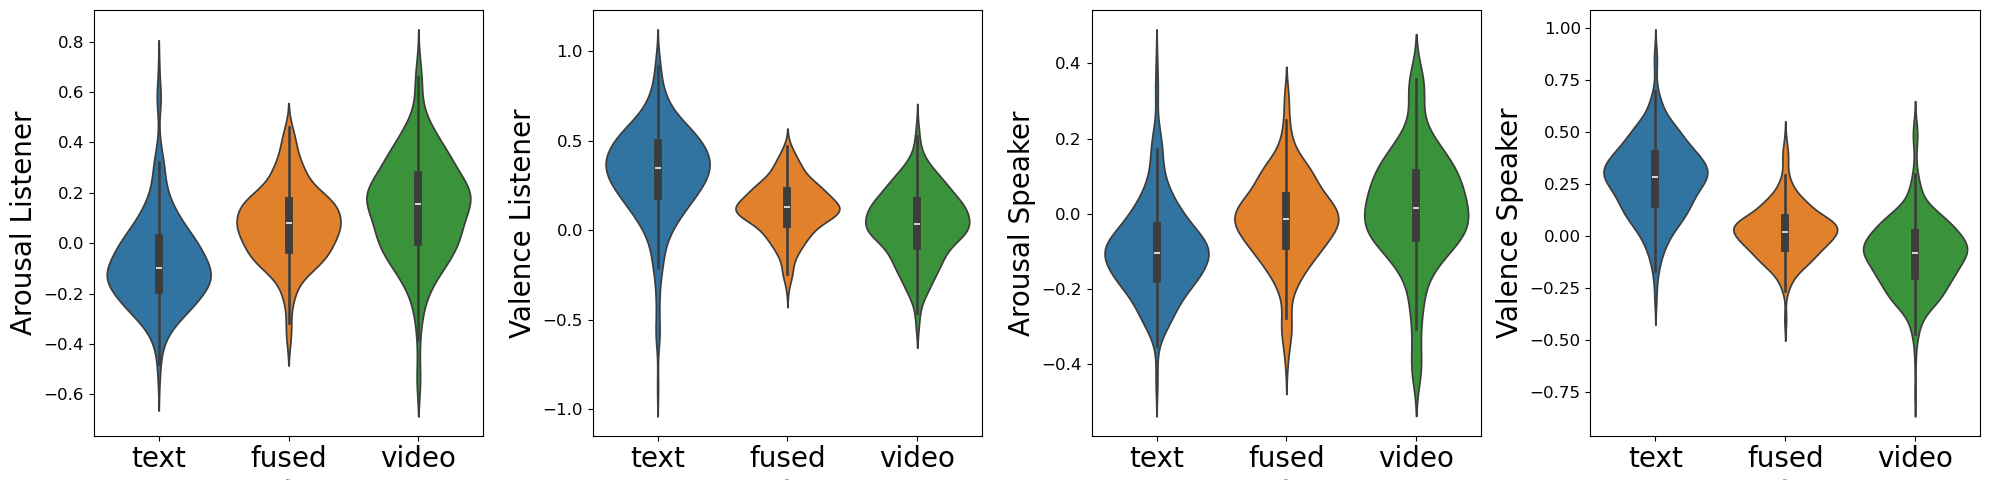

In [12]:
unmodified_master_df= pd.read_csv(current_dir+'/mEX_all_predictions.csv')
unmodified_video_df= pd.read_csv(current_dir+'/mEX_all_predictions.csv')
modified_master_df = pd.read_csv(current_dir+'/results/lexllm_video_predictions/test_with_'+str(optimal_weight/100)+'/mEX_fusion_'+str(optimal_weight/100)+'.csv')

#Delete exchanges with issues
modified_master_df.drop(modified_master_df[modified_master_df.speaker_id == 'sub_14_conv_4'].index, inplace=True)
modified_master_df.drop(modified_master_df[modified_master_df.speaker_id == 'sub_13_conv_7'].index, inplace=True)
modified_master_df.drop(modified_master_df[modified_master_df.speaker_id == 'sub_12_conv_7'].index, inplace=True)
modified_master_df.drop(modified_master_df[modified_master_df.speaker_id == 'sub_12_conv_7'].index, inplace=True)
modified_master_df.drop(modified_master_df[modified_master_df.speaker_id == 'sub_7_conv_1'].index, inplace=True)
modified_master_df = modified_master_df.reset_index(drop=True)

#check if all three dataframes have the same number of rows after dropping the problematic exchanges
print(f"Unmodified Master DF rows: {len(unmodified_master_df)}")
print(f"Unmodified Video DF rows: {len(unmodified_video_df)}")
print(f"Modified Master DF rows: {len(modified_master_df)}")   

graphs_dir = os.path.join(current_dir, 'graphs')
os.makedirs(graphs_dir, exist_ok=True)

unmodified_VA = unmodified_master_df[['arousal_speaker', 'valence_speaker', 'arousal_listener', 'valence_listener', 'mimicry']].copy()
unmodified_VA['source'] = 'text'
modified_VA = modified_master_df[['arousal_speaker', 'valence_speaker', 'arousal_listener', 'valence_listener', 'mimicry']].copy()
modified_VA['source'] = 'fused'
unmodified_video_VA = unmodified_video_df[['arousal_speaker_video', 'valence_speaker_video', 'arousal_listener_video', 'valence_listener_video', 'mimicry']].copy()
unmodified_video_VA = unmodified_video_VA.rename(columns={
    'arousal_speaker_video': 'arousal_speaker',
    'valence_speaker_video': 'valence_speaker',
    'arousal_listener_video': 'arousal_listener',
    'valence_listener_video': 'valence_listener'
})
unmodified_video_VA['source'] = 'video'

valence_arousal_compare = pd.concat([unmodified_VA, modified_VA, unmodified_video_VA], ignore_index=True)

# Build one combined figure with all four metrics side by side in the requested order.
plot_order = ['arousal_listener', 'valence_listener', 'arousal_speaker', 'valence_speaker']
display_names = {
    'arousal_listener': 'Arousal Listener',
    'valence_listener': 'Valence Listener',
    'arousal_speaker': 'Arousal Speaker',
    'valence_speaker': 'Valence Speaker'
}
source_order = ['text', 'fused', 'video']
source_palette = {
    'text': '#1f77b4',
    'fused': '#ff7f0e',
    'video': '#2ca02c'
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True)
for ax, metric in zip(axes, plot_order):
    sns.violinplot(
        data=valence_arousal_compare,
        x='source',
        y=metric,
        order=source_order,
        palette=source_palette,
        ax=ax
    )
    label = display_names.get(metric, metric.replace('_', ' ').title())
    # ax.set_title(label, fontsize=18)
    ax.set_xlabel('Source', fontsize=0)
    ax.set_ylabel(label, fontsize=20)
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=12)

fig.tight_layout()
fig.savefig(os.path.join(graphs_dir, 'valence_arousal_combined.svg'))
fig.savefig(os.path.join(graphs_dir, 'valence_arousal_combined.pdf'))

stacked_valence_arousal_compare = valence_arousal_compare.stack([0], future_stack=True)
print(stacked_valence_arousal_compare)

# print the mean arousal and valence for each source and their metrics for the violin plot
print(valence_arousal_compare.groupby('source').mean())
print(valence_arousal_compare.groupby('source').std())

# len(master_df.id.unique())


### create master file with every prediction

In [13]:
modified_master_df = pd.read_csv(current_dir+'/results/lexllm_video_predictions/test_with_'+str(optimal_weight/100)+'/mEX_fusion_'+str(optimal_weight/100)+'.csv')
mex['arousal_listener_fused'] = modified_master_df['arousal_listener']
mex['valence_listener_fused'] = modified_master_df['valence_listener']
mex['arousal_speaker_fused'] = modified_master_df['arousal_speaker']
mex['valence_speaker_fused'] = modified_master_df['valence_speaker']
mex['mimicry_fused'] = mex['mimicry_video_face']
mex['id'] = mex['speaker_id']


mex.to_csv(current_dir + '/mEX_all_predictions.csv', index=False)

# Get most influential feature

In [14]:
def find_relevant_feature_per_class_count(pattern_array, count_array, label,attribute_lst, desired_features): 
    #print(f'Exchange classified as {label}')

    label -= 1

    #print(f'Exchange classified as {label}')

    #get the number of patterns that apply to this instance
    counts = count_array[:,int(label)]
    #get the patterns that cover this instance
    patterns = pattern_array[counts.astype(np.bool_)]
    #Slice the patterns into a list of item objects
    pattern_items = [pattern.Items for pattern in patterns]

    #check if they are the same
    #print(f"The number of patterns that cover this class is: {len(patterns)}")
    #print(f"The number of pattern item lists for this class is: {len(pattern_items)}")

    pattern_features = []
    for item_list in pattern_items:
        single_pat_features = [item.Feature[0] for item in item_list]
        #print(len(pat_features))
        #print(len(set(pat_features)))
        pattern_features.append(set(single_pat_features))


    feature_count = [0] * len(attribute_lst)
    feature_count_supports = [0] * len(attribute_lst)



    for idx in range(len(pattern_features)):
        #print(pattern_features)
        for i in range(len(attribute_lst)):
            if attribute_lst[i] in pattern_features[idx]:
                feature_count[i] += 1
                feature_count_supports[i] += 1*patterns[idx].Supports[label]



    #print(feature_count)
    #print(feature_count_supports)

    sorted_lst = sorted([(val, idx) for (idx, val) in enumerate(feature_count)])
    #print(sorted_lst)
    #print(attribute_lst[sorted_lst[-1][1]])


    #print('Most relevant features per pattern count')

    feature_array = []


    feature_array_speaker = []
    feature_array_listener = []

    for feature_num in range(1,desired_features+1):
        #print(attribute_lst[sorted_lst[-feature_num][1]])
        feature_array.append(attribute_lst[sorted_lst[-feature_num][1]])

    #print('Most relevant features related to speaker')

    for feature_num in range(1,len(sorted_lst)):
        if len(feature_array_speaker) < desired_features: 
            candidate_attribute = attribute_lst[sorted_lst[-feature_num][1]]
            if candidate_attribute[:2] == 's_' or 'speaker' in str(candidate_attribute):
                #print(attribute_lst[sorted_lst[-feature_num][1]])
                feature_array_speaker.append(attribute_lst[sorted_lst[-feature_num][1]])
        else:
            break

    #print('Most relevant features related to listener')

    for feature_num in range(1,len(sorted_lst)):
        if len(feature_array_listener) < desired_features: 
            candidate_attribute = attribute_lst[sorted_lst[-feature_num][1]]
            if not (candidate_attribute[:2] == 's_' or 'speaker' in str(candidate_attribute)):
                #print(attribute_lst[sorted_lst[-feature_num][1]])
                feature_array_listener.append(attribute_lst[sorted_lst[-feature_num][1]])
        else:
            break




    return feature_array, feature_array_listener, feature_array_speaker

def find_relevant_feature_per_class_support(pattern_array, count_array, label,attribute_lst,desired_features): 
    #print(f'Exchange classified as {label}')

    label -= 1

    #get the number of patterns that apply to this instance
    counts = count_array[:,int(label)]
    #get the patterns that cover this instance
    patterns = pattern_array[counts.astype(np.bool_)]
    #Slice the patterns into a list of item objects
    pattern_items = [pattern.Items for pattern in patterns]
    
    #for i in range(5):
    #    print(patterns[i].Supports)

    #check if they are the same

    pattern_features = []
    for item_list in pattern_items:
        single_pat_features = [item.Feature[0] for item in item_list]
        #print(len(pat_features))
        #print(len(set(pat_features)))
        pattern_features.append(set(single_pat_features))


    feature_count = [0] * len(attribute_lst)
    feature_count_supports = [0] * len(attribute_lst)


    for idx in range(len(pattern_features)):
        #print(pattern_features)
        for i in range(len(attribute_lst)):
            if attribute_lst[i] in pattern_features[idx]:
                feature_count[i] += 1
                feature_count_supports[i] += 1*patterns[idx].Supports[label]


    sorted_lst = sorted([(val, idx) for (idx, val) in enumerate(feature_count_supports)])

    #print('Most relevant features per pattern support')

    feature_array = []
    feature_array_speaker = []
    feature_array_listener = []
    for feature_num in range(1,desired_features+1):
        #print(attribute_lst[sorted_lst[-feature_num][1]])
        feature_array.append(attribute_lst[sorted_lst[-feature_num][1]])

    #print('Most relevant features related to speaker')

    for feature_num in range(1,len(sorted_lst)):
        if len(feature_array_speaker) < desired_features: 
            candidate_attribute = attribute_lst[sorted_lst[-feature_num][1]]
            if candidate_attribute[:2] == 's_' or 'speaker' in str(candidate_attribute):
                #print(attribute_lst[sorted_lst[-feature_num][1]])
                feature_array_speaker.append(attribute_lst[sorted_lst[-feature_num][1]])
        else:
            break

    #print('Most relevant features related to listener')

    for feature_num in range(1,len(sorted_lst)):
        if len(feature_array_listener) < desired_features: 
            candidate_attribute = attribute_lst[sorted_lst[-feature_num][1]]
            if not (candidate_attribute[:2] == 's_' or 'speaker' in str(candidate_attribute)):
                #print(attribute_lst[sorted_lst[-feature_num][1]])
                feature_array_listener.append(attribute_lst[sorted_lst[-feature_num][1]])
        else:
            break



    return feature_array, feature_array_listener, feature_array_speaker


def print_feature_with_values(exchange_df, feature_array):
    for idx in range(len(exchange_df)):
        #print(idx)
        for item in feature_array:
            print(f'{item} : {exchange_df.loc[idx,item]:.2f}')
    return 0

def get_feature_with_values(exchange_df, feature_array):
    values = []
    for idx in range(len(exchange_df)):
        #print(idx)
        for item in feature_array:
            values.append((item,exchange_df.loc[idx,item]))
            #print(f'{item} : {exchange_df.loc[idx,item]:.2f}')
    return values

    
def get_most_relevant_features(classifier, exchange_df,criterion,attribute_lst, prediction, feature_num):
    #get most influential patterns
    emerging_patterns = classifier.EmergingPatterns #access the patterns mined by the classifier
    pattern_list = [] #patterns that cover the exchange
    for instance in exchange_df.to_numpy(): 
        for pattern in emerging_patterns:
            if pattern.IsMatch(instance):
                pattern_list.append(pattern)   
                #print(type(instance))
    count_lst = [pattern.Counts for pattern in pattern_list]
    pattern_arr = np.array(pattern_list)
    #print(len(pattern_list))
    count_arr = np.array(count_lst)
    #print(len(count_arr))

    #print(pattern_list[:5])


    #print(f'Exchange classified as {prediction}')

    #ifs important features by pattern support

    if str(criterion) == 'support':
        ifs, ifs_l, ifs_s = find_relevant_feature_per_class_support(pattern_arr,count_arr,prediction,attribute_lst,feature_num)
        return ifs, ifs_l, ifs_s 
    if str(criterion) == 'count':
        ifc, ifc_l, ifc_s = find_relevant_feature_per_class_count(pattern_arr,count_arr,prediction,attribute_lst,feature_num)
        return ifc, ifc_l, ifc_s 
    else:
        print('Invalid criterion, please select "support" to address the support patterns have over instances and "count" for just counting the times a feature appears in the patterns')
        return [],[],[]


def get_most_relevant_feature(classifier, exchange_df,role,attribute_lst, prediction):
    #get most influential patterns
    emerging_patterns = classifier.EmergingPatterns #access the patterns mined by the classifier
    pattern_list = [] #patterns that cover the exchange
    for instance in exchange_df.to_numpy(): 
        for pattern in emerging_patterns:
            if pattern.IsMatch(instance):
                pattern_list.append(pattern)   
                #print(type(instance))
    count_lst = [pattern.Counts for pattern in pattern_list]
    pattern_arr = np.array(pattern_list)
    #print(len(pattern_list))
    count_arr = np.array(count_lst)


    #ifs important features by pattern support
    ifs, ifs_l, ifs_s = find_relevant_feature_per_class_support(pattern_arr,count_arr,prediction,attribute_lst,3,4)

    print()

    #ifc important features by pattern count (how many times they appear in the patterns that cover the instance)
    ifc, ifc_l, ifc_s = find_relevant_feature_per_class_count(pattern_arr,count_arr,prediction,attribute_lst,3)
 
    #print(exchange_df)
    print('Most relevant features per pattern support')
    print_feature_with_values(exchange_df,ifs)
    print('Most relevant support features related to listener')
    print_feature_with_values(exchange_df,ifs_l)
    print('Most relevant support features related to speaker')
    print_feature_with_values(exchange_df,ifs_s)
    return ifs, ifc


In [15]:
# Safer pretty-printer for influential features with mixed dtypes
def print_feature_with_values(exchange_df, feature_array):
    for idx in range(len(exchange_df)):
        for item in feature_array:
            value = exchange_df.loc[idx, item]
            if isinstance(value, (int, float, np.integer, np.floating)):
                print(f'{item} : {value:.2f}')
                continue

            # Some features are categorical values serialized as strings (e.g., '0', 'neutral').
            try:
                numeric_value = float(value)
                print(f'{item} : {numeric_value:.2f}')
            except (TypeError, ValueError):
                print(f'{item} : {value}')
    return 0

### Single exchange

In [16]:
#Text example
#get an exchange from the database
random_idx = 7
processed_exchange = mex.iloc[[random_idx]]
processed_exchange = processed_exchange.reset_index(drop=True)
#get the prediction for the exchange
y_pred = processed_exchange['pbc_t_2'].values[0]
#prepare the exchange for the model
processed_exchange = processed_exchange[att_lst]
#get relevant features for the exchange
influential,influential_l,influential_s = get_most_relevant_features(pbc, processed_exchange,'support',att_lst, y_pred,4)
#print the influential features with their values for the exchange
print('Most relevant features per pattern support')
print_feature_with_values(processed_exchange,influential)
print(get_feature_with_values(processed_exchange,influential))
print('Most relevant support features related to listener')
print_feature_with_values(processed_exchange,influential_l)
print(get_feature_with_values(processed_exchange,influential_l))
print('Most relevant support features related to speaker')
print_feature_with_values(processed_exchange,influential_s)
print(get_feature_with_values(processed_exchange,influential_s))

Most relevant features per pattern support
l_word_len : 10.00
emotional_reaction : 0.00
s_word_len : 18.00
dominance_listener : 0.17
[('l_word_len', 10.0), ('emotional_reaction', '0'), ('s_word_len', 18.0), ('dominance_listener', 0.17319999999999997)]
Most relevant support features related to listener
l_word_len : 10.00
emotional_reaction : 0.00
dominance_listener : 0.17
valence_listener : -0.07
[('l_word_len', 10.0), ('emotional_reaction', '0'), ('dominance_listener', 0.17319999999999997), ('valence_listener', -0.06520000000000001)]
Most relevant support features related to speaker
s_word_len : 18.00
dominance_speaker : -0.05
valence_speaker : -0.17
speaker_sentiment : negative
[('s_word_len', 18.0), ('dominance_speaker', -0.04799999999999999), ('valence_speaker', -0.17133333333333334), ('speaker_sentiment', 'negative')]


In [18]:
# Fused example 

random_idx = 7
processed_exchange = mex.iloc[[random_idx]]
processed_exchange = processed_exchange.reset_index(drop=True)
processed_exchange['arousal_listener'] = processed_exchange['arousal_listener_fused']
processed_exchange['valence_listener'] = processed_exchange['valence_listener_fused']
processed_exchange['arousal_speaker'] = processed_exchange['arousal_speaker_fused']
processed_exchange['valence_speaker'] = processed_exchange['valence_speaker_fused']
#get the prediction for the exchange
y_pred = processed_exchange['pbc_va_2'].values[0]
#prepare the exchange for the model
processed_exchange = processed_exchange[att_lst]
#get relevant features for the exchange
influential,influential_l,influential_s = get_most_relevant_features(pbc, processed_exchange,'support',att_lst, y_pred,4)
#print the influential features with their values for the exchange
print('Most relevant features per pattern support')
print_feature_with_values(processed_exchange,influential)
print(get_feature_with_values(processed_exchange,influential))
print('Most relevant support features related to listener')
print_feature_with_values(processed_exchange,influential_l)
print(get_feature_with_values(processed_exchange,influential_l))
print('Most relevant support features related to speaker')
print_feature_with_values(processed_exchange,influential_s)
print(get_feature_with_values(processed_exchange,influential_s))
processed_exchange

Most relevant features per pattern support
l_word_len : 10.00
dominance_speaker : -0.05
valence_speaker : 0.05
arousal_listener : 0.00
[('l_word_len', 10.0), ('dominance_speaker', -0.04799999999999999), ('valence_speaker', 0.0534573786278474), ('arousal_listener', 9.860542345535572e-05)]
Most relevant support features related to listener
l_word_len : 10.00
arousal_listener : 0.00
dominance_listener : 0.17
valence_listener : -0.09
[('l_word_len', 10.0), ('arousal_listener', 9.860542345535572e-05), ('dominance_listener', 0.17319999999999997), ('valence_listener', -0.0928927499946397)]
Most relevant support features related to speaker
dominance_speaker : -0.05
valence_speaker : 0.05
arousal_speaker : 0.02
s_word_len : 18.00
[('dominance_speaker', -0.04799999999999999), ('valence_speaker', 0.0534573786278474), ('arousal_speaker', 0.0202383827754958), ('s_word_len', 18.0)]


,s_word_len,l_word_len,arousal_listener,valence_listener,who,sentiment,emotional_reaction,interpretations,explorations,intent,arousal_speaker,valence_speaker,speaker_who,speaker_sentiment,dominance_speaker,dominance_listener,mimicry
0,18.0,10.0,0.000099,-0.092893,0,negative,0,0,0,9,0.020238,0.053457,2,negative,-0.048,0.1732,1.0


## Get most influential text and video features from PBC4cip master file

In [17]:
recalculate = False

### 3 levels

In [18]:
if recalculate == True:
    master_file = pd.read_csv(current_dir + '/mEX_all_predictions.csv')
    from tqdm.auto import tqdm
    categorical_columns = ['who', 'sentiment', 'sentiment_speaker','intent', 'speaker_who','interpretations', 'emotional_reaction', 'explorations','who']
    for col in categorical_columns:
        if col in master_file.columns:
            if col == 'speaker_sentiment' or col == 'sentiment':
                master_file[col] = master_file[col].astype('string')
            else:
                master_file[col] = master_file[col].astype('int')
                master_file[col] = master_file[col].astype('string')
    # master_file = master_file.head()
    changes = ['','_fused']
    change_idx = 0
    for change_idx in [0,1]:

        influential_list = []
        influential_l_list = []
        influential_s_list = []
        #text 
        file_with_features = master_file.copy()


        av_features = ['arousal_speaker', 'valence_speaker', 'arousal_listener', 'valence_listener', 'mimicry']

        for feature in av_features:
            file_with_features[feature] = file_with_features[feature + changes[change_idx]]


        for idx in tqdm(range(len(file_with_features)), desc=f"3-level {changes[change_idx] or 'text'}", leave=False):
        #for idx in range(8):

            individual_exchange_df =  file_with_features.loc[[idx],att_lst].copy().reset_index(drop=True)
            if changes[change_idx] == '':
                prediction = file_with_features.loc[idx,['pbc_t_3']].to_list()[0]
            elif changes[change_idx] == '_fused':
                prediction = file_with_features.loc[idx,['pbc_va_3']].to_list()[0]
            
            influential,influential_l,influential_s = get_most_relevant_features(pbc, master_file.loc[[idx],att_lst],'support',att_lst, prediction ,4)

            influential_list.append(get_feature_with_values(individual_exchange_df,influential))
            influential_l_list.append(get_feature_with_values(individual_exchange_df,influential_l))
            influential_s_list.append(get_feature_with_values(individual_exchange_df,influential_s))
        
        #print(influential_l_list)
        master_file['influential'+changes[change_idx]] = influential_list
        master_file['influential_l'+changes[change_idx]] = influential_l_list
        master_file['influential_s'+changes[change_idx]] = influential_s_list
    master_file.to_csv('features_master_file.csv', index=False)

### Binary

In [19]:
if recalculate == True:
    master_file = pd.read_csv(current_dir + '/mEX_all_predictions.csv')
    categorical_columns = ['who', 'sentiment', 'sentiment_speaker','intent', 'speaker_who','interpretations', 'emotional_reaction', 'explorations','who']
    for col in categorical_columns:
        if col in master_file.columns:
            if col == 'speaker_sentiment' or col == 'sentiment':
                master_file[col] = master_file[col].astype('string')
            else:
                master_file[col] = master_file[col].astype('int')
                master_file[col] = master_file[col].astype('string')
    # master_file = master_file.head()
    changes = ['','_fused']
    change_idx = 0
    for change_idx in [0,1]:

        influential_list = []
        influential_l_list = []
        influential_s_list = []
        #text 
        file_with_features = master_file.copy()


        av_features = ['arousal_speaker', 'valence_speaker', 'arousal_listener', 'valence_listener', 'mimicry']

        for feature in av_features:
            file_with_features[feature] = file_with_features[feature + changes[change_idx]]


        for idx in tqdm(range(len(file_with_features)), desc=f"2-level {changes[change_idx] or 'text'}", leave=False):
        #for idx in range(8):

            individual_exchange_df =  file_with_features.loc[[idx],att_lst].copy().reset_index(drop=True)
            if changes[change_idx] == '':
                prediction = file_with_features.loc[idx,['pbc_t_2']].to_list()[0]
            elif changes[change_idx] == '_fused':
                prediction = file_with_features.loc[idx,['pbc_va_2']].to_list()[0]
            
            influential,influential_l,influential_s = get_most_relevant_features(pbc, master_file.loc[[idx],att_lst],'support',att_lst, prediction ,4)

            influential_list.append(get_feature_with_values(individual_exchange_df,influential))
            influential_l_list.append(get_feature_with_values(individual_exchange_df,influential_l))
            influential_s_list.append(get_feature_with_values(individual_exchange_df,influential_s))
        
        #print(influential_l_list)
        master_file['influential'+changes[change_idx]] = influential_list
        master_file['influential_l'+changes[change_idx]] = influential_l_list
        master_file['influential_s'+changes[change_idx]] = influential_s_list
    master_file.to_csv('features_binary_file.csv', index=False)

## Graph top features

{'Model': ['2-levels $t$', '2-levels $t+v$', '3-levels $t$', '3-levels $t+v$'], 's_word_len': [100, 98, 105, 99], 'l_word_len': [270, 269, 280, 282], 'arousal_listener': [52, 54, 57, 55], 'valence_listener': [79, 79, 81, 85], 'who': [0, 0, 3, 3], 'sentiment': [102, 103, 89, 87], 'emotional_reaction': [197, 197, 197, 202], 'interpretations': [8, 8, 7, 5], 'explorations': [0, 0, 0, 0], 'intent': [39, 38, 32, 32], 'arousal_speaker': [61, 60, 54, 52], 'valence_speaker': [90, 97, 88, 98], 'speaker_who': [0, 0, 0, 0], 'speaker_sentiment': [26, 25, 18, 17], 'dominance_speaker': [73, 75, 81, 81], 'dominance_listener': [143, 137, 148, 142], 'mimicry': [0, 0, 0, 0]}
            Model  s_word_len  l_word_len  l_arousal  l_valence  who  \
0    2-levels $t$         100         270         52         79    0   
1  2-levels $t+v$          98         269         54         79    0   
2    3-levels $t$         105         280         57         81    3   
3  3-levels $t+v$          99         282      

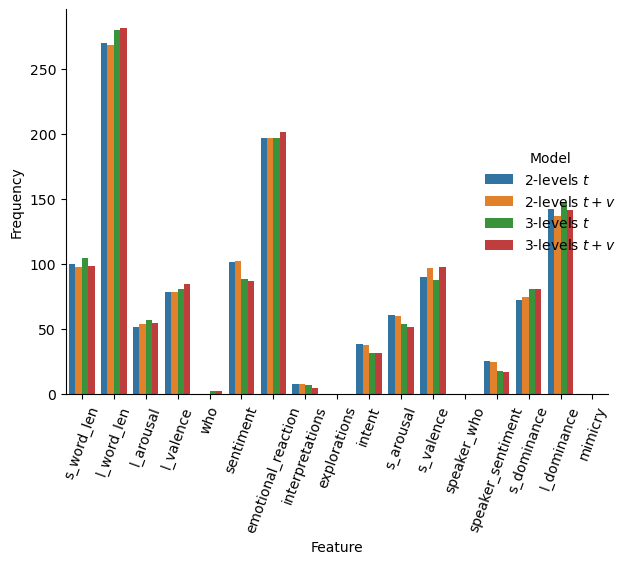

In [20]:
import matplotlib.pyplot as plt

feature_file_3 = pd.read_csv(current_dir + '/features_master_file.csv')
feature_file_2 = pd.read_csv(current_dir + '/features_binary_file.csv')

feature_file_3



frequency_dic_txt_3 = {}
for att in att_lst:
    frequency_dic_txt_3.update({att: 0})
for j in range(len(feature_file_3['influential'])):
    feat_list = eval(feature_file_3['influential'][j])
    for i in range(len(feat_list)):
        #if(feat_list[i][0] == 'l_word_len'):
        #    print(f"{feat_list} {j} {feature_file_3['speaker_utterance'][j]} {feature_file_3['listener_utterance'][j]}")
        frequency_dic_txt_3[feat_list[i][0]] += 1
        #print(feat_list[i][0])



frequency_dic_vid_3 = {}
for att in att_lst:
    frequency_dic_vid_3.update({att: 0})
for j in range(len(feature_file_3['influential_fused'])):
    feat_list = eval(feature_file_3['influential_fused'][j])
    for i in range(len(feat_list)):
        #if(feat_list[i][0] == 'l_word_len'):
        #    print(f"{feat_list} {j} {feature_file_3['speaker_utterance'][j]} {feature_file_3['listener_utterance'][j]}")
        frequency_dic_vid_3[feat_list[i][0]] += 1
        #print(feat_list[i][0])




frequency_dic_txt_2 = {}
for att in att_lst:
    frequency_dic_txt_2.update({att: 0})
for j in range(len(feature_file_2['influential'])):
    feat_list = eval(feature_file_2['influential'][j])
    for i in range(len(feat_list)):
        #if(feat_list[i][0] == 'l_word_len'):
        #    print(f"{feat_list} {j} {feature_file_3['speaker_utterance'][j]} {feature_file_3['listener_utterance'][j]}")
        frequency_dic_txt_2[feat_list[i][0]] += 1
        #print(feat_list[i][0])




frequency_dic_vid_2 = {}
for att in att_lst:
    frequency_dic_vid_2.update({att: 0})
for j in range(len(feature_file_2['influential_fused'])):
    feat_list = eval(feature_file_2['influential_fused'][j])
    for i in range(len(feat_list)):
        #if(feat_list[i][0] == 'l_word_len'):
        #    print(f"{feat_list} {j} {feature_file_3['speaker_utterance'][j]} {feature_file_3['listener_utterance'][j]}")
        frequency_dic_vid_2[feat_list[i][0]] += 1
        #print(feat_list[i][0])



dict_list = [frequency_dic_txt_2, frequency_dic_vid_2, frequency_dic_txt_3, frequency_dic_vid_3]


frequency_dic = {'Model': ['2-levels $t$', '2-levels $t+v$', '3-levels $t$', '3-levels $t+v$']}
for att in att_lst:
    frequency_dic.update({att: []})


# frequency_dic_txt_3.pop('l_word_len')
# frequency_dic_txt_3.pop('s_word_len')
# frequency_dic_vid_3.pop('l_word_len')
# frequency_dic_vid_3.pop('s_word_len')
# frequency_dic_txt_2.pop('l_word_len')
# frequency_dic_txt_2.pop('s_word_len')
# frequency_dic_vid_2.pop('l_word_len')
# frequency_dic_vid_2.pop('s_word_len')
# frequency_dic.pop('l_word_len')
# frequency_dic.pop('s_word_len')



for dict in dict_list:
    for key in dict:
        frequency_dic[key].append(dict[key])

print(frequency_dic)


df_frequency = pd.DataFrame.from_dict(frequency_dic)
df_frequency = df_frequency.rename(columns={"valence_speaker": "s_valence", "arousal_speaker": "s_arousal","dominance_speaker": "s_dominance","valence_listener": "l_valence", "arousal_listener": "l_arousal","dominance_listener": "l_dominance","predictions_ER": "ER"})





print(df_frequency)

for x in dict_list[1:]: 
    continue

dfm = pd.melt(df_frequency, id_vars="Model", var_name="feature", value_name="frequency")

bar_plot = plt.figure(figsize=(7, 5))
ax = sns.barplot(x='feature', y='frequency', hue='Model', data=dfm)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_tick_params(rotation=70)
ax.set_xlabel('Feature')
ax.set_ylabel('Frequency')

sns.move_legend(ax, bbox_to_anchor=(0.75, 0.5), loc='center left', frameon=False)

bar_plot.savefig(current_dir+"/graphs/top_influential_plot.svg",bbox_inches='tight') 



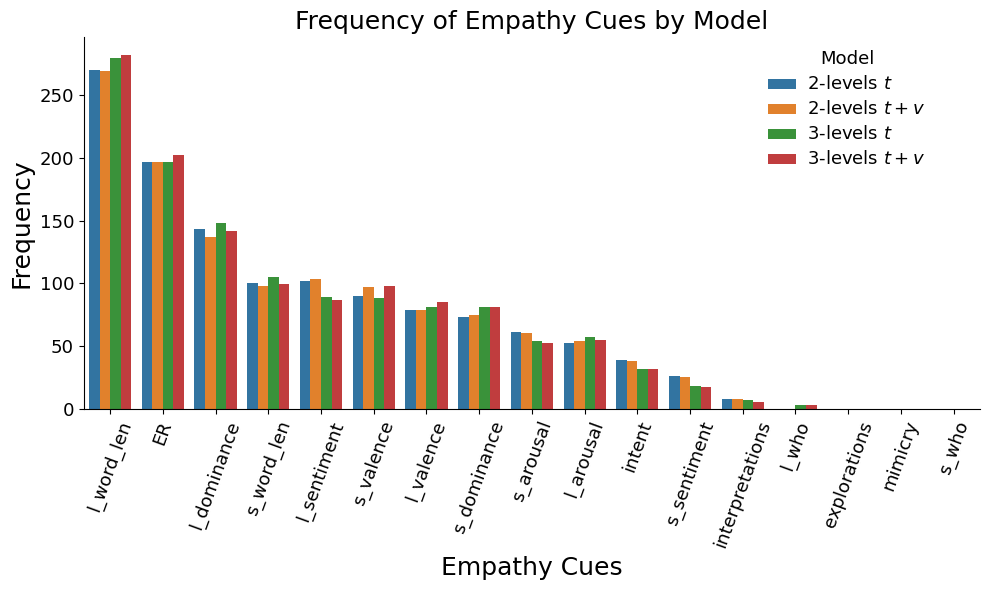

In [21]:
# Create the bar plot with increased bar width
def format_feature_name(feature_name):
    if feature_name == 'emotional_reaction':
        return 'ER'
    if feature_name == 'who':
        return 'l_who'
    if feature_name == 'sentiment':
        return 'l_sentiment'
    if 'speaker' in feature_name:
        return f's_{feature_name[8:]}'
    return feature_name

dfm_plot = dfm.copy()
dfm_plot['feature_display'] = dfm_plot['feature'].apply(format_feature_name)

# Order features by total frequency (highest to lowest).
feature_order = (
    dfm_plot.groupby('feature_display', as_index=False)['frequency']
    .sum()
    .sort_values('frequency', ascending=False)['feature_display']
    .tolist()
)

bar_plot = plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='feature_display',
    y='frequency',
    hue='Model',
    data=dfm_plot,
    order=feature_order,
    width=0.8
  )

# Customize the plot
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_tick_params(rotation=70)
ax.set_xlabel('Empathy Cues', fontsize=18)
ax.set_ylabel('Frequency', fontsize=18)
ax.set_title('Frequency of Empathy Cues by Model', fontsize=18)

# Increase font size of tick labels
ax.tick_params(axis='both', which='major', labelsize=13)

# Move the legend and increase its font size
sns.move_legend(ax, bbox_to_anchor=(0.75, 1), loc='upper left', frameon=False)
plt.setp(ax.get_legend().get_texts(), fontsize=13)
plt.setp(ax.get_legend().get_title(), fontsize=13)

# Show the plot
plt.tight_layout()
plt.savefig(current_dir+'/graphs/bar_plot.pdf', format='pdf')
plt.show()

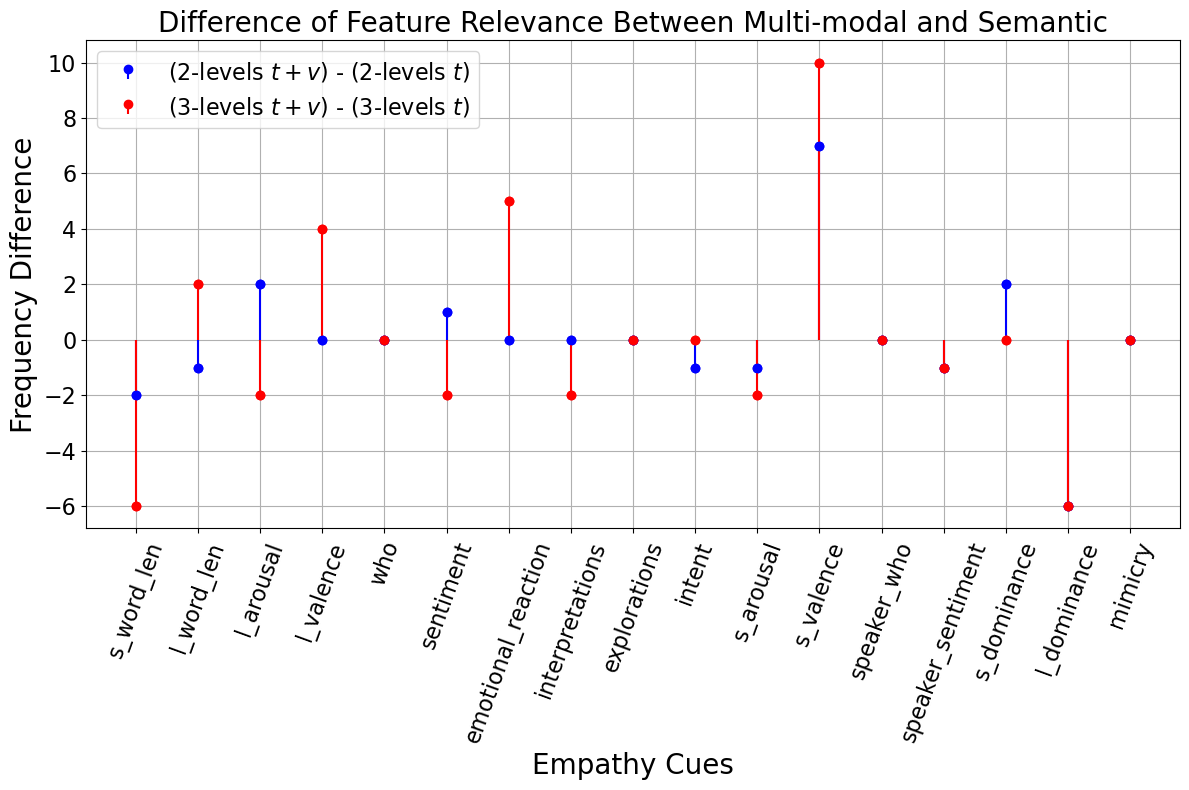

In [22]:
# Calculate the differences
df_frequency

import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_frequency is your DataFrame
# Example structure of df_frequency:
# df_frequency = pd.DataFrame({
#     'Model': ['model1', 'model2', 'model3', 'model4'],
#     'feature1': [value1, value2, value3, value4],
#     'feature2': [value5, value6, value7, value8],
#     'feature3': [value9, value10, value11, value12]
# })

# Exclude the "Model" column and calculate the differences
differences_1_0 = df_frequency.iloc[1, 1:] - df_frequency.iloc[0, 1:]
differences_3_2 = df_frequency.iloc[3, 1:] - df_frequency.iloc[2, 1:]

# Create the lollipop plot
plt.figure(figsize=(12, 8))

# Plot differences between row 1 and row 0
plt.stem(differences_1_0.index, differences_1_0.values, basefmt=" ", linefmt='b-', markerfmt='bo', label='(2-levels $t+v$) - (2-levels $t$)')
plt.scatter(differences_1_0.index, differences_1_0.values, color='blue', zorder=3)

# Plot differences between row 3 and row 2
plt.stem(differences_3_2.index, differences_3_2.values, basefmt=" ", linefmt='r-', markerfmt='ro', label='(3-levels $t+v$) - (3-levels $t$)')
plt.scatter(differences_3_2.index, differences_3_2.values, color='red', zorder=3)

# Customize the plot
plt.title('Difference of Feature Relevance Between Multi-modal and Semantic', fontsize=20)
plt.xlabel('Empathy Cues', fontsize=20)
plt.ylabel('Frequency Difference', fontsize=20)
plt.grid(True)
plt.xticks(rotation=70, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)



plt.tight_layout()
plt.savefig(current_dir+'/graphs/lollipop_plot.pdf', format='pdf')

# Show the plot
plt.show()

# Inter annotator agreement



In [23]:

from sklearn.metrics import cohen_kappa_score


# Process the video exchanges data for inter-annotator agreement and classification metrics
video_exchanges_df = pd.read_csv(main_dir + 'exchanges/video_exchanges_disconsensus.csv')
video_exchanges_df = video_exchanges_df[video_exchanges_df['usable'] != 0]
video_exchanges_df = video_exchanges_df[video_exchanges_df['final_label'] != 0]

video_exchanges_df['empathy_1_3'] = video_exchanges_df.apply(lambda x: 1 if (x['empathy_1'] == 2 or x['empathy_1'] == 1)  else (2 if x['empathy_1'] == 3 else 3), axis = 1)
video_exchanges_df['empathy_2_3'] = video_exchanges_df.apply(lambda x: 1 if (x['empathy_2'] == 2 or x['empathy_2'] == 1)  else (2 if x['empathy_2'] == 3 else 3), axis = 1)
video_exchanges_df['empathy_1_2'] = video_exchanges_df.apply(lambda x: 1 if (x['empathy_1_3'] == 1)  else 2, axis = 1)
video_exchanges_df['empathy_2_2'] = video_exchanges_df.apply(lambda x: 1 if (x['empathy_2_3'] == 1)  else 2, axis = 1)
video_exchanges_df['final_label_binary'] = video_exchanges_df.apply(lambda x: 1 if (x['final_label'] == 1)  else 2, axis = 1)

video_exchanges_df.drop(video_exchanges_df[video_exchanges_df.id == 'sub_14_conv_4'].index, inplace=True)
video_exchanges_df.drop(video_exchanges_df[video_exchanges_df.id == 'sub_13_conv_7'].index, inplace=True)
video_exchanges_df.drop(video_exchanges_df[video_exchanges_df.id == 'sub_12_conv_7'].index, inplace=True)
video_exchanges_df.drop(video_exchanges_df[video_exchanges_df.id == 'sub_12_conv_7'].index, inplace=True)
video_exchanges_df.drop(video_exchanges_df[video_exchanges_df.id == 'sub_7_conv_1'].index, inplace=True)
video_exchanges_df = video_exchanges_df.reset_index(drop=True)
video_exchanges_df.to_csv(main_dir + '/exchanges/video_exchanges_disconsensus_reduced.csv', index= False)


#get three-level Cohen's kappa index for the two annotators
cohen_kappa_index_3 = cohen_kappa_score(video_exchanges_df['empathy_1_3'], video_exchanges_df['empathy_2_3'])
#obtain classification metrics for each annotator compared to the final label for the three-level classification
metrics_1_3 = get_classification_metrics(video_exchanges_df['final_label'], video_exchanges_df['empathy_1_3'])
metrics_1_3['cem'] = cem_utils.get_cem(video_exchanges_df['empathy_1_3'], video_exchanges_df[['final_label']], target_column='final_label')
metrics_2_3 = get_classification_metrics(video_exchanges_df['final_label'], video_exchanges_df['empathy_2_3'])
metrics_2_3['cem'] = cem_utils.get_cem(video_exchanges_df['empathy_2_3'], video_exchanges_df[['final_label']], target_column='final_label')
print('three_levels')
print(f'Cohen Kappa: {cohen_kappa_index_3}')
print(f'First annotator: ')
print(metrics_1_3)
print(f'Second annotator: ')
print(metrics_2_3)

#get two-level Cohen's kappa index for the two annotators
cohen_kappa_index_2 = cohen_kappa_score(video_exchanges_df['empathy_1_2'], video_exchanges_df['empathy_2_2'])
metrics_1_2 = get_classification_metrics(video_exchanges_df['final_label_binary'], video_exchanges_df['empathy_1_2'])
metrics_1_2['cem'] = cem_utils.get_cem(video_exchanges_df['empathy_1_2'], video_exchanges_df[['final_label_binary']], target_column='final_label_binary')
metrics_2_2 = get_classification_metrics(video_exchanges_df['final_label_binary'], video_exchanges_df['empathy_2_2'])
metrics_2_2['cem'] = cem_utils.get_cem(video_exchanges_df['empathy_2_2'], video_exchanges_df[['final_label_binary']], target_column='final_label_binary')
print('two_levels')
print(f'Cohen Kappa: {cohen_kappa_index_2}')
print(f'First annotator: ')
print(metrics_1_2)
print(f'Second annotator: ')
print(metrics_2_2)

#print the distribution of labels for the final label, empathy_1_3, empathy_2_3, empathy_1_2, and empathy_2_2
print('Label distribution:')
print(video_exchanges_df['final_label'].value_counts())
print(video_exchanges_df['empathy_1_3'].value_counts())
print(video_exchanges_df['empathy_2_3'].value_counts())
print(video_exchanges_df['empathy_1_2'].value_counts())
print(video_exchanges_df['empathy_2_2'].value_counts())



three_levels
Cohen Kappa: 0.23744827810901525
First annotator: 
{'accuracy': 0.7322580645161291, 'f1': 0.6758899789795154, 'precision': 0.6862413714052829, 'recall': 0.6778361202271187, 'conf_matrix': array([[137,  13,   0],
       [ 28,  29,  22],
       [  7,  13,  61]]), 'cem': 0.8131575013458974}
Second annotator: 
{'accuracy': 0.7258064516129032, 'f1': 0.7048827501942977, 'precision': 0.7020752583979329, 'recall': 0.7152284211074647, 'conf_matrix': array([[114,  28,   8],
       [  4,  49,  26],
       [ 10,   9,  62]]), 'cem': 0.8190373902870799}
two_levels
Cohen Kappa: 0.379594837444862
First annotator: 
{'accuracy': 0.8451612903225807, 'f1': 0.8449289257576389, 'precision': 0.8511543646781261, 'recall': 0.8472916666666667, 'conf_matrix': array([[137,  13],
       [ 35, 125]]), 'cem': 0.8782973197754956}
Second annotator: 
{'accuracy': 0.8387096774193549, 'f1': 0.8369725272413648, 'precision': 0.8464114010989011, 'recall': 0.8362499999999999, 'conf_matrix': array([[114,  36],
  

# Experiment order

In [25]:
import random
import math
import itertools
import pandas as pd



plutchik_emo_dic = {0:'anger', 1: 'disgust', 2: 'fear', 3: 'joy', 4: 'anticipation', 5: 'sadness', 6: 'surprise' , 7: 'trust'}
empathy_level_dic = {0: 'low', 1: 'medium', 2: 'high'}

# this only works for Iterable[Iterable]
def is_latin_rectangle(rows):
    valid = True
    for row in rows:
        if len(set(row)) < len(row):
            valid = False
    if valid and rows:
        for i, val in enumerate(rows[0]):
            col = [row[i] for row in rows]
            if len(set(col)) < len(col):
                valid = False
                break
    return valid

def is_latin_square(rows):
    return is_latin_rectangle(rows) and len(rows) == len(rows[0])

# : prepare the input
n = 8
items = list(range(1, n + 1))
# shuffle items
random.shuffle(items)
# number of permutations



def latin_square(items, shuffle=True):
    result = []
    for elems in itertools.permutations(items):
        valid = True
        for i, elem in enumerate(elems):
            orthogonals = [x[i] for x in result] + [elem]
            if len(set(orthogonals)) < len(orthogonals):
                valid = False
                break
        if valid:
            result.append(elems)
    if shuffle:
        random.shuffle(result)
    return result

ltn_sq_1 = latin_square(items)
for row in ltn_sq_1:
    print(row)
print(is_latin_square(ltn_sq_1))

type(ltn_sq_1)

experiment_squares = []

#print(experiment_squares[0][1])

for i in range(n):
    experiment_squares.append(list(ltn_sq_1[i]))

for i in range(n):
    for j in range(n):
        experiment_squares[i][j] = (plutchik_emo_dic[experiment_squares[i][j]-1], random.choice(['low','medium','high']))


for row in experiment_squares:
    print(row)


#for item in experiment_squares: 
#    print(item)

latin_sqr_df = pd.DataFrame(experiment_squares).T


print(latin_sqr_df)

number_of_square = 2

# latin_sqr_df.to_csv('./useful_database_subsets/experiment_square_'+str(number_of_square)+'.csv')

#random.choice(['low','medium','high'])

(6, 4, 2, 3, 8, 1, 5, 7)
(2, 3, 6, 4, 5, 7, 8, 1)
(8, 1, 5, 7, 6, 4, 2, 3)
(4, 6, 3, 2, 1, 8, 7, 5)
(3, 2, 4, 6, 7, 5, 1, 8)
(5, 7, 8, 1, 2, 3, 6, 4)
(1, 8, 7, 5, 4, 6, 3, 2)
(7, 5, 1, 8, 3, 2, 4, 6)
True
[('sadness', 'medium'), ('joy', 'high'), ('disgust', 'high'), ('fear', 'high'), ('trust', 'high'), ('anger', 'high'), ('anticipation', 'medium'), ('surprise', 'low')]
[('disgust', 'high'), ('fear', 'high'), ('sadness', 'low'), ('joy', 'low'), ('anticipation', 'low'), ('surprise', 'low'), ('trust', 'high'), ('anger', 'high')]
[('trust', 'low'), ('anger', 'low'), ('anticipation', 'medium'), ('surprise', 'high'), ('sadness', 'low'), ('joy', 'high'), ('disgust', 'high'), ('fear', 'medium')]
[('joy', 'high'), ('sadness', 'high'), ('fear', 'high'), ('disgust', 'medium'), ('anger', 'medium'), ('trust', 'high'), ('surprise', 'medium'), ('anticipation', 'medium')]
[('fear', 'high'), ('disgust', 'low'), ('joy', 'high'), ('sadness', 'low'), ('surprise', 'low'), ('anticipation', 'medium'), ('ange

## Get graph for feature agumentation lambda parameter 

In [26]:
results_dir = current_dir+'/results'
videos_dir = results_dir + '/video_predictions'
print(videos_dir+ '/mini_weights')


metrics_list = []
mini_weights_dir = videos_dir + '/mini_weights'

for root, dirs, files in os.walk(mini_weights_dir):
    for file in files:
        if file == 'metrics.txt':
            folder_name = os.path.basename(root)
            metrics_path = os.path.join(root, file)
            with open(metrics_path, 'r') as f:
                metrics_data = f.read()
                metrics_list.append((folder_name, metrics_data))

# Sort the list by folder name
metrics_list.sort(key=lambda x: x[0])

print(metrics_list)

/home/haru/Desktop/projects/MultimodalEX/classifiers/PBC4emp/results/video_predictions/mini_weights
[('w_0.01', 'Accuracy: 0.4311111111111111\nCEM: 0.5882705749157779Accuracy: 0.4311111111111111\nCEM: 0.5882705749157779'), ('w_0.02', 'Accuracy: 0.4266666666666667\nCEM: 0.5859781990213027Accuracy: 0.4266666666666667\nCEM: 0.5859781990213027'), ('w_0.03', 'Accuracy: 0.4266666666666667\nCEM: 0.5841471737947713Accuracy: 0.4266666666666667\nCEM: 0.5841471737947713'), ('w_0.04', 'Accuracy: 0.4266666666666667\nCEM: 0.5855649105637155'), ('w_0.05', 'Accuracy: 0.4311111111111111\nCEM: 0.5871232987358675'), ('w_0.06', 'Accuracy: 0.43555555555555553\nCEM: 0.5913276324492743'), ('w_0.07', 'Accuracy: 0.4311111111111111\nCEM: 0.5888733913699987'), ('w_0.08', 'Accuracy: 0.43555555555555553\nCEM: 0.592290919961789'), ('w_0.09', 'Accuracy: 0.44\nCEM: 0.5962584476085064'), ('w_0.1', 'Accuracy: 0.4488888888888889\nCEM: 0.602049284687172'), ('w_0.11', 'Accuracy: 0.4488888888888889\nCEM: 0.6010050645822573

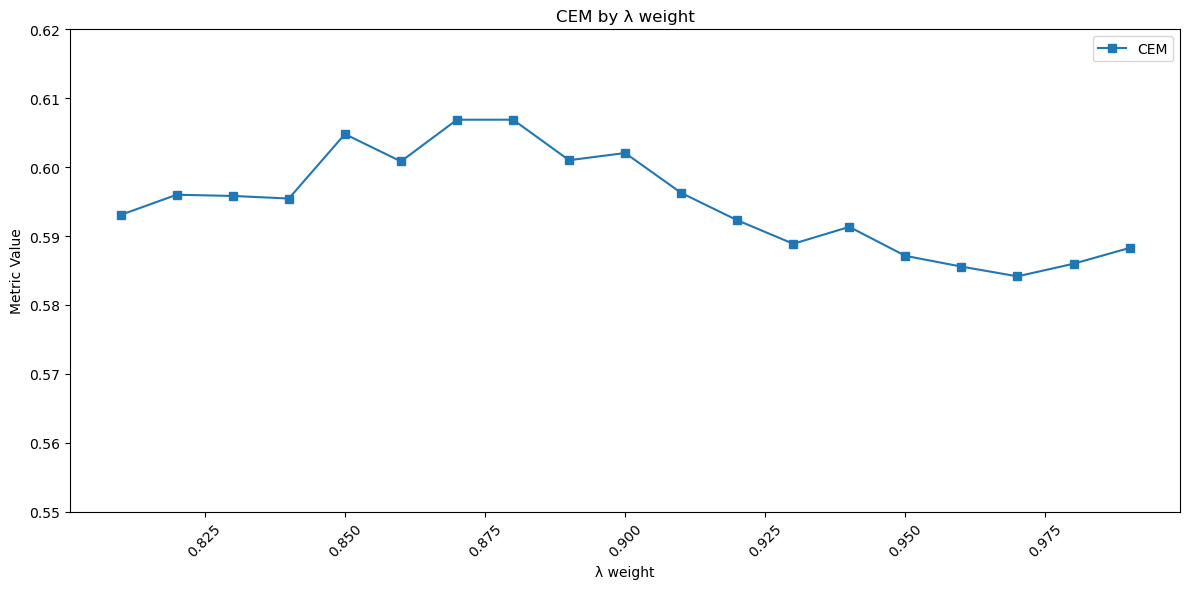

In [27]:
import matplotlib.pyplot as plt

# Extract accuracy and CEM from metrics_list
x_names = []
accuracies = []
cems = []

for folder_name, metrics_data in metrics_list:
    lines = metrics_data.split('\n')
    # Find lines containing Accuracy and CEM
    acc = None
    cem = None
    for line in lines:
        # if line.startswith('Accuracy:'):
        #     try:
        #         acc = float(line.split(':')[1].strip())
        #     except:
        #         acc = None
        if line.startswith('CEM:'):
            try:
                cem = float(line.split(':')[1].strip())
            except:
                cem = None
    # if acc is not None and cem is not None:
    if cem is not None:
        x_names.append(1-float(folder_name[-3:]))  # Use last 4 characters of folder name
        # accuracies.append(acc)
        cems.append(cem)

plt.figure(figsize=(12, 6))
# plt.plot(x_names, accuracies, marker='o', label='Accuracy')
plt.plot(x_names, cems, marker='s', label='CEM')
plt.ylim(0.55, 0.62)
plt.xlabel('λ weight')
plt.ylabel('Metric Value')
plt.title('CEM by λ weight')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Processing directory: /home/haru/Desktop/projects/MultimodalEX/classifiers/PBC4emp/results/lexllm_video_predictions/test_with_0.8
Processing directory: /home/haru/Desktop/projects/MultimodalEX/classifiers/PBC4emp/results/lexllm_video_predictions/test_with_1.0
Processing directory: /home/haru/Desktop/projects/MultimodalEX/classifiers/PBC4emp/results/lexllm_video_predictions/test_with_0.2
Processing directory: /home/haru/Desktop/projects/MultimodalEX/classifiers/PBC4emp/results/lexllm_video_predictions/test_with_0.4
Processing directory: /home/haru/Desktop/projects/MultimodalEX/classifiers/PBC4emp/results/lexllm_video_predictions/test_with_0.6
Processing directory: /home/haru/Desktop/projects/MultimodalEX/classifiers/PBC4emp/results/lexllm_video_predictions/test_with_0.9
Processing directory: /home/haru/Desktop/projects/MultimodalEX/classifiers/PBC4emp/results/lexllm_video_predictions/test_with_0.0
Processing directory: /home/haru/Desktop/projects/MultimodalEX/classifiers/PBC4emp/results

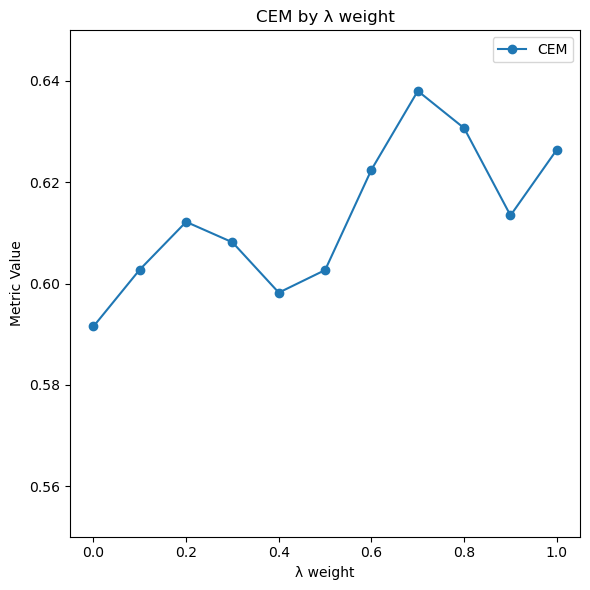

In [28]:
results_dir = current_dir + '/results'
videos_dir = results_dir + '/lexllm_video_predictions'

metrics_list = []
# Only include directories starting with 'test_with' and skip any path under 'ml'.
for root, dirs, files in os.walk(videos_dir):
    # Prevent descending into any directory named 'ml'.
    dirs[:] = [d for d in dirs if d != 'ml']

    if os.path.basename(root).startswith('test_with') and len(os.path.basename(root)) == len('test_with_0.9'):
        print(f"Processing directory: {root}")
        for file in files:
            if file == 'metrics.txt':
                folder_name = os.path.basename(root)
                metrics_path = os.path.join(root, file)
                with open(metrics_path, 'r') as f:
                    metrics_data = f.read()
                    metrics_list.append((folder_name, metrics_data))

print(metrics_list)
# Sort the list by folder name
metrics_list.sort(key=lambda x: x[0])

# Extract accuracy from metrics_list
x_names = []
accuracies = []

for folder_name, metrics_data in metrics_list:
    lines = metrics_data.split('\n')
    acc = None
    for line in lines:
        if line.startswith('CEM:'):
            try:
                acc = float(line.split(':')[1].strip())
            except:
                acc = None
    if acc is not None:
        x_names.append(float(folder_name[-3:]))  # Use last 4 characters of folder name)
        accuracies.append(acc)

plt.figure(figsize=(6, 6))
plt.plot(x_names, accuracies, marker='o', label='CEM')
plt.ylim(0.55, 0.65)
plt.xlabel('λ weight')
plt.ylabel('Metric Value')
plt.title('CEM by λ weight')
#plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(current_dir + '/graphs/cem_by_lambda_weight.pdf', format='pdf')
plt.show()

# Statistical Analysis

In [29]:
# McNemar pairwise comparisons and LaTeX table generation.
import itertools
import numpy as np
import pandas as pd
from mlxtend.evaluate import mcnemar_table
from mlxtend.evaluate import mcnemar

def run_mcnemar_pairwise(df, target_col='empathy_binary', prediction_suffix='_2', corrected=True, alpha=0.05, excluded_prefixes=()):
    """
    Run McNemar tests one-by-one for every pair of prediction columns ending in `prediction_suffix`.
    The ground-truth labels are taken from `target_col`.
    """
    pred_cols = [
        col for col in df.columns
        if col.endswith(prediction_suffix)
        and col != target_col
        and not any(col.startswith(prefix) for prefix in excluded_prefixes)
    ]

    if len(pred_cols) < 2:
        print(f"Need at least two prediction columns ending with '{prediction_suffix}'. Found: {pred_cols}")
        return pd.DataFrame()

    print(f"Target column: {target_col}")
    print(f"Prediction columns ({len(pred_cols)}): {pred_cols}")
    if excluded_prefixes:
        print(f"Excluded prefixes: {excluded_prefixes}")

    results = []
    total_pairs = len(pred_cols) * (len(pred_cols) - 1) // 2

    for idx, (col_a, col_b) in enumerate(itertools.combinations(pred_cols, 2), start=1):
        pair_df = df[[target_col, col_a, col_b]].dropna().copy()
        pair_df[target_col] = pair_df[target_col].astype(int)
        pair_df[col_a] = pair_df[col_a].astype(int)
        pair_df[col_b] = pair_df[col_b].astype(int)

        y_target = pair_df[target_col].to_numpy()
        y_model1 = pair_df[col_a].to_numpy()
        y_model2 = pair_df[col_b].to_numpy()

        table = mcnemar_table(
            y_target=y_target,
            y_model1=y_model1,
            y_model2=y_model2
        )
        chi2, p_value = mcnemar(ary=table, corrected=corrected)

        print(f"\n[{idx}/{total_pairs}] {col_a} vs {col_b}")
        print("Contingency table:")
        print(table)
        print(f"chi2={chi2:.6f}, p-value={p_value:.6g}")

        results.append({
            'model_1': col_a,
            'model_2': col_b,
            'n_samples': len(pair_df),
            'chi2': chi2,
            'p_value': p_value,
            'significant': bool(p_value < alpha),
        })

    # Keep the same order as printed in the loop: one model against all following models.
    results_df = pd.DataFrame(results).reset_index(drop=True)
    return results_df

def _latex_escape(text):
    return str(text).replace('_', r'\_')

def _default_model_display_name(column_name):
    display_map = {
        # PBC4emp
        'pbc_t_2': r'PBC4emp \textit{t}',
        'pbc_va_2': r'PBC4emp \textit{t+av}',
        'pbc_vam_2': r'PBC4emp \textit{t+av+m}',
        'pbc_m_2': r'PBC4emp \textit{m}',
        'pbc_t_3': r'PBC4emp \textit{t}',
        'pbc_va_3': r'PBC4emp \textit{t+av}',
        'pbc_vam_3': r'PBC4emp \textit{t+av+m}',
        'pbc_m_3': r'PBC4emp \textit{m}',
        # BERT
        'bert_2': r'BERT',
        'bert_3': r'BERT',
        # RF
        'rf_t_2': r'RF \textit{t}',
        'rf_va_2': r'RF \textit{t+av}',
        'rf_vam_2': r'RF \textit{t+av+m}',
        'rf_m_2': r'RF \textit{m}',
        'rf_t_3': r'RF \textit{t}',
        'rf_va_3': r'RF \textit{t+av}',
        'rf_vam_3': r'RF \textit{t+av+m}',
        'rf_m_3': r'RF \textit{m}',
    }
    if column_name in display_map:
        return display_map[column_name]

    # Keep all LLM entries consistent as GPT-4o, even when a specific key is not listed above.
    if column_name.startswith('llm_'):
        parts = column_name.split('_')
        cue = parts[1] if len(parts) >= 2 else ''
        cue_map = {
            't': 't',
            'va': 'av',
            'vam': 'av+m',
            'm': 'm',
        }
        cue_label = cue_map.get(cue, cue)
        if cue_label:
            return rf'GPT-4o \textit{{{cue_label}}}'
        return r'GPT-4o'

    return _latex_escape(column_name)

def build_mcnemar_latex_table(
    section_results,
    alpha=0.05,
    caption=r'McNemar pairwise comparisons (p-values). Only pairs with $p < 0.05$ are shown. \\ \small \textit{t} = text-only, \textit{av} = arousal and valence, \textit{m} = mimicry.',
    label='tab:mcnemar',
    tabcolsep='6pt',
    focus_prefix='pbc_'
    ):
    """
    Build a LaTeX table from McNemar result DataFrames.

    section_results: list of tuples (section_title, results_df), e.g.
        [('2-level', mcnemar_results_2), ('3-level', mcnemar_results_3)]
    focus_prefix: if set, keep only pairs where at least one model starts with this prefix.
    """
    lines = [
        r'\begin{table}[!tbh]',
        r'\begin{center}',
        rf'\caption{{{caption}}}',
        rf'\label{{{label}}}',
        rf'\setlength{{\tabcolsep}}{{{tabcolsep}}}',
        r'\begin{tabular}{l l c}',
        r'\toprule',
        r'\textbf{Model A} & \textbf{Model B} & \textbf{p-value} \\',
        r'\midrule',
    ]

    included_any_section = False

    for section_title, results_df in section_results:
        if results_df is None or results_df.empty:
            continue

        significant_df = results_df[results_df['p_value'] < alpha].copy()
        if significant_df.empty:
            continue

        if focus_prefix:
            model_1_has_prefix = significant_df['model_1'].astype(str).str.startswith(focus_prefix)
            model_2_has_prefix = significant_df['model_2'].astype(str).str.startswith(focus_prefix)
            significant_df = significant_df[model_1_has_prefix | model_2_has_prefix].copy()

            # Put the focused model family on the left for cleaner grouped rows.
            swap_mask = (~significant_df['model_1'].astype(str).str.startswith(focus_prefix)) & significant_df['model_2'].astype(str).str.startswith(focus_prefix)
            if swap_mask.any():
                significant_df.loc[swap_mask, ['model_1', 'model_2']] = significant_df.loc[swap_mask, ['model_2', 'model_1']].to_numpy()

        if significant_df.empty:
            continue

        included_any_section = True
        lines.append(rf'\multicolumn{{3}}{{l}}{{\textbf{{{section_title}}}}} \\')
        lines.append(r'\midrule')

        # Keep original order from the McNemar loop (already one-by-one order).
        grouped = significant_df.groupby('model_1', sort=False)
        for model_a, group in grouped:
            group_rows = list(group.itertuples(index=False))
            model_a_name = _default_model_display_name(model_a)
            row_count = len(group_rows)

            first = group_rows[0]
            model_b_name = _default_model_display_name(first.model_2)
            p_text = f"{first.p_value:.5f}"
            lines.append(rf'\multirow[t]{{{row_count}}}{{*}}{{{model_a_name}}}')
            lines.append(rf'  & {model_b_name} & {p_text} \\')

            for row in group_rows[1:]:
                model_b_name = _default_model_display_name(row.model_2)
                p_text = f"{row.p_value:.5f}"
                lines.append(rf'  & {model_b_name} & {p_text} \\')

            lines.append(r'\addlinespace[2pt]')

        # Remove trailing addlinespace in this section for cleaner output.
        if lines[-1] == r'\addlinespace[2pt]':
            lines.pop()

        lines.append(r'\midrule')

    if not included_any_section:
        lines.append(r'\multicolumn{3}{l}{No significant pairwise differences found.} \\')
        lines.append(r'\midrule')

    # Replace last midrule with bottomrule.
    if lines[-1] == r'\midrule':
        lines[-1] = r'\bottomrule'
    else:
        lines.append(r'\bottomrule')

    lines.extend([
        r'\end{tabular}',
        r'\end{center}',
        r'\end{table}',
    ])

    return '\n'.join(lines)

# Run pairwise comparisons for both label granularities (RF included).
mcnemar_results_2 = run_mcnemar_pairwise(
    mex,
    target_col='empathy_binary',
    prediction_suffix='_2',
    corrected=True,
    alpha=0.05
)

mcnemar_results_3 = run_mcnemar_pairwise(
    mex,
    target_col='empathy',
    prediction_suffix='_3',
    corrected=True,
    alpha=0.05
)

# Save raw pairwise outputs.
mcnemar_results_2.to_csv(current_dir + '/mcnemar_pairwise_results_2_level.csv', index=False)
mcnemar_results_3.to_csv(current_dir + '/mcnemar_pairwise_results_3_level.csv', index=False)

# Build and save LaTeX table with significant pairs only, focused on PBC4emp comparisons.
mcnemar_latex_table = build_mcnemar_latex_table(
    section_results=[('2-level', mcnemar_results_2), ('3-level', mcnemar_results_3)],
    alpha=0.05,
    label='tab:mcnemar',
    focus_prefix='pbc_'
    )

with open(current_dir + '/mcnemar_pairwise_table.tex', 'w') as f:
    f.write(mcnemar_latex_table)

print(mcnemar_latex_table)

Target column: empathy_binary
Prediction columns (13): ['rf_t_2', 'rf_m_2', 'rf_va_2', 'rf_vam_2', 'pbc_t_2', 'pbc_m_2', 'pbc_va_2', 'pbc_vam_2', 'bert_2', 'llm_va_2', 'llm_m_2', 'llm_vam_2', 'llm_t_2']

[1/78] rf_t_2 vs rf_m_2
Contingency table:
[[173   1]
 [  1 135]]
chi2=0.500000, p-value=0.4795

[2/78] rf_t_2 vs rf_va_2
Contingency table:
[[167   7]
 [  7 129]]
chi2=0.071429, p-value=0.789268

[3/78] rf_t_2 vs rf_vam_2
Contingency table:
[[167   7]
 [  6 130]]
chi2=0.000000, p-value=1

[4/78] rf_t_2 vs pbc_t_2
Contingency table:
[[160  14]
 [ 30 106]]
chi2=5.113636, p-value=0.0237385

[5/78] rf_t_2 vs pbc_m_2
Contingency table:
[[157  17]
 [ 34 102]]
chi2=5.019608, p-value=0.0250618

[6/78] rf_t_2 vs pbc_va_2
Contingency table:
[[155  19]
 [ 55  81]]
chi2=16.554054, p-value=4.72828e-05

[7/78] rf_t_2 vs pbc_vam_2
Contingency table:
[[142  32]
 [ 18 118]]
chi2=3.380000, p-value=0.0659921

[8/78] rf_t_2 vs bert_2
Contingency table:
[[158  16]
 [ 15 121]]
chi2=0.000000, p-value=1

[9/

In [30]:
# Significant-differences table excluding PBC4emp comparisons.
non_pbc_results_2 = mcnemar_results_2[
    ~mcnemar_results_2['model_1'].astype(str).str.startswith('pbc_')
    & ~mcnemar_results_2['model_2'].astype(str).str.startswith('pbc_')
]
non_pbc_results_3 = mcnemar_results_3[
    ~mcnemar_results_3['model_1'].astype(str).str.startswith('pbc_')
    & ~mcnemar_results_3['model_2'].astype(str).str.startswith('pbc_')
]

mcnemar_latex_table_non_pbc = build_mcnemar_latex_table(
    section_results=[('2-level', non_pbc_results_2), ('3-level', non_pbc_results_3)],
    alpha=0.05,
    label='tab:mcnemar_non_pbc',
    focus_prefix=None
)

with open(current_dir + '/mcnemar_pairwise_table_non_pbc.tex', 'w') as f:
    f.write(mcnemar_latex_table_non_pbc)

print(mcnemar_latex_table_non_pbc)

\begin{table}[!tbh]
\begin{center}
\caption{McNemar pairwise comparisons (p-values). Only pairs with $p < 0.05$ are shown. \\ \small \textit{t} = text-only, \textit{av} = arousal and valence, \textit{m} = mimicry.}
\label{tab:mcnemar_non_pbc}
\setlength{\tabcolsep}{6pt}
\begin{tabular}{l l c}
\toprule
\textbf{Model A} & \textbf{Model B} & \textbf{p-value} \\
\midrule
\multicolumn{3}{l}{\textbf{2-level}} \\
\midrule
\multirow[t]{3}{*}{RF \textit{t}}
  & GPT-4o \textit{av} & 0.00536 \\
  & GPT-4o \textit{av+m} & 0.03365 \\
  & GPT-4o \textit{t} & 0.00044 \\
\addlinespace[2pt]
\multirow[t]{3}{*}{RF \textit{m}}
  & GPT-4o \textit{av} & 0.00488 \\
  & GPT-4o \textit{av+m} & 0.03589 \\
  & GPT-4o \textit{t} & 0.00044 \\
\addlinespace[2pt]
\multirow[t]{3}{*}{RF \textit{t+av}}
  & GPT-4o \textit{av} & 0.00360 \\
  & GPT-4o \textit{av+m} & 0.02930 \\
  & GPT-4o \textit{t} & 0.00037 \\
\addlinespace[2pt]
\multirow[t]{3}{*}{RF \textit{t+av+m}}
  & GPT-4o \textit{av} & 0.00268 \\
  & GPT-4o \texti